In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/DTI5125-TEST')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
PARTITIONS_CSV = "partitions.csv"   # output of book_partitioner.ipynb

TEST_SIZE      = 0.2    # 80/20 train-test split
RANDOM_STATE   = 42
CV_FOLDS       = 5      # stratified k-fold cross-validation

# Genres in a consistent display order
GENRES = ["autobiography", "fantasy", "horror", "romance", "sci-fi"]


In [3]:
import pandas as pd

partitions = pd.read_csv(PARTITIONS_CSV)

In [4]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

# 1. Create a dictionary to map genre names to numbers (BERT needs integers)
unique_genres = sorted(partitions['genre'].unique())
genre_to_id = {genre: i for i, genre in enumerate(unique_genres)}
id_to_genre = {i: genre for i, genre in enumerate(unique_genres)}

print(f"Mapping labels: {genre_to_id}")

# 2. Use your existing dataframe to split the data
# We keep the raw text columns here!
train_df, test_df = train_test_split(
    partitions,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=partitions['genre']
)

# 3. Create the format BERT needs (a dictionary of lists)
train_data = {
    "text": train_df["text"].tolist(),
    "label": [genre_to_id[g] for g in train_df["genre"]]
}

test_data = {
    "text": test_df["text"].tolist(),
    "label": [genre_to_id[g] for g in test_df["genre"]]
}

# 4. Now turn these into HuggingFace Datasets
train_dataset = Dataset.from_dict(train_data)
test_dataset = Dataset.from_dict(test_data)

print(f"Ready for BERT: {len(train_dataset)} training samples.")

Mapping labels: {'autobiography': 0, 'fantasy': 1, 'horror': 2, 'romance': 3, 'sci-fi': 4}
Ready for BERT: 800 training samples.


In [5]:
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

# 1. Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 2. Tokenize function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

# 3. Apply to datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# 4. Set the format so PyTorch can read the data
tokenized_test.set_format("torch")

# 5. Create the dataloader for the report function
test_dataloader = DataLoader(tokenized_test, batch_size=16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [6]:
import numpy as np
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score

# Load BERT with a "classification head" on top (for your 5 genres)
# num_labels must match the number of unique genres in your GENRES list
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(GENRES)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [8]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # Evaluate after every epoch (1 full pass through data)
    learning_rate=2e-5,           # Standard rate for fine-tuning BERT
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,           # 3 passes are usually enough for BERT to learn
    weight_decay=0.01,
)

In [9]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# This is the "fit" equivalent
trainer.train()

# Evaluate final performance
final_results = trainer.evaluate()
print(f"Final BERT Accuracy: {final_results['eval_accuracy']:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.242646,0.970000
2,No log,0.067738,0.985000
3,No log,0.062981,0.985000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final BERT Accuracy: 0.9850


In [10]:
import torch
import torch.nn.functional as F

def predict_genre(text, model, tokenizer, id_to_genre):
    # 1. Tokenize the input text
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)

    # 2. Ensure model is in evaluation mode
    model.eval()

    # 3. Move input to the same device as the model (CPU or GPU)
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 4. Get the model's prediction
    with torch.no_grad():
        outputs = model(**inputs)

    # 5. Convert raw logits to probabilities
    probs = F.softmax(outputs.logits, dim=-1)

    # Print all probabilities
    for i, genre_name in enumerate(GENRES):
      print(f"{genre_name}: {probs[0][i].item():.2%}")

    # 6. Get the index of the highest probability
    predicted_id = torch.argmax(probs, dim=-1).item()

    # 7. Map back to genre name
    predicted_genre = id_to_genre[predicted_id]
    confidence = probs[0][predicted_id].item()

    return predicted_genre, confidence

# New sample texts for each genre
test_passages = {
    "Fantasy": "The ancient wizard traced a glowing sigil in the air, his staff pulsing with the forbidden power of the star-fallen crystals that bound the broken realm together.",
    "Romance": "Their hands brushed for a fleeting second, sending a jolt of recognition through her heart that told her, more than any whispered promise ever could, that he was the missing piece to her soul.",
    "Sci-Fi": "The neural-link interface hummed as it synchronized with the station’s mainframe, allowing his consciousness to drift through the vast, cold geometry of the sector’s encrypted data streams.",
    "Horror": "An oppressive silence filled the corridor, broken only by the rhythmic, wet scratching behind the drywall, a sound that suggested something not quite human was waiting for the light to fail.",
    "Autobiography": "Reflecting on those formative winters in the valley, I realized that the scarcity of our circumstances had not been a burden, but the very crucible in which my resolve was tempered."
}

print("--- Running BERT Final Exam ---")
for genre, text in test_passages.items():
    print(f"\nTesting Genre: {genre}")
    pred, conf = predict_genre(text, model, tokenizer, id_to_genre)
    print(f"Result: {pred.upper()} (Confidence: {conf:.2%})")

--- Running BERT Final Exam ---

Testing Genre: Fantasy
autobiography: 0.58%
fantasy: 92.46%
horror: 2.86%
romance: 1.76%
sci-fi: 2.34%
Result: FANTASY (Confidence: 92.46%)

Testing Genre: Romance
autobiography: 2.00%
fantasy: 59.09%
horror: 13.08%
romance: 12.35%
sci-fi: 13.48%
Result: FANTASY (Confidence: 59.09%)

Testing Genre: Sci-Fi
autobiography: 0.76%
fantasy: 1.41%
horror: 0.60%
romance: 0.55%
sci-fi: 96.68%
Result: SCI-FI (Confidence: 96.68%)

Testing Genre: Horror
autobiography: 0.78%
fantasy: 60.67%
horror: 5.83%
romance: 3.37%
sci-fi: 29.35%
Result: FANTASY (Confidence: 60.67%)

Testing Genre: Autobiography
autobiography: 0.43%
fantasy: 0.75%
horror: 97.83%
romance: 0.47%
sci-fi: 0.53%
Result: HORROR (Confidence: 97.83%)


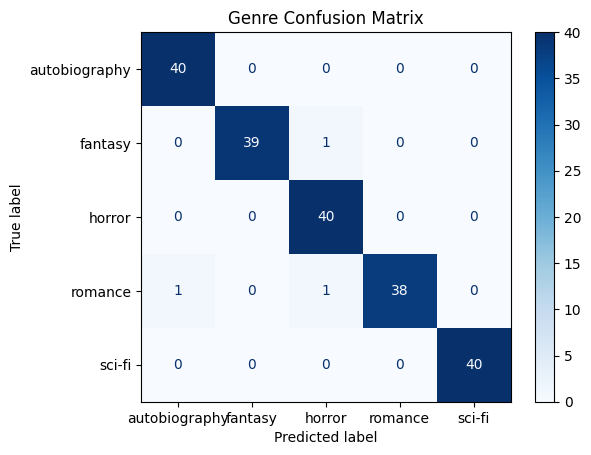

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get predictions for your whole test set
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# 2. Create the matrix
cm = confusion_matrix(labels, preds)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GENRES)
disp.plot(cmap=plt.cm.Blues)
plt.title("Genre Confusion Matrix")
plt.show()

In [12]:
# Save both the model and the tokenizer
save_directory = "./bert_genre_model"

model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"Model and Tokenizer saved to: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and Tokenizer saved to: ./bert_genre_model


In [24]:
import torch

# This defines the variable 'device' so your function can find it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_bert_report(model, dataloader, id_to_genre):
    print("Starting evaluation...")
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # If batch is a dictionary, use it. If it's a list/tuple, extract the first item.
            if isinstance(batch, (list, tuple)):
                data = batch[0]
            else:
                data = batch

            # Move the specific input tensors to device
            # We specifically look for the keys that BERT needs
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)

            # Handle labels - check for both 'label' and 'labels'
            label_key = 'label' if 'label' in data else 'labels'
            labels = data[label_key].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Map indices back to genre names
    pred_names = [id_to_genre[i] for i in all_preds]
    true_names = [id_to_genre[i] for i in all_labels]

    # Print the report
    sorted_genres = [id_to_genre[i] for i in sorted(id_to_genre.keys())]
    print("\n--- BERT Classification Report ---")
    print(classification_report(true_names, pred_names, target_names=sorted_genres))

# Call the function with your prepared variables
get_bert_report(model, test_dataloader, id_to_genre)

Starting evaluation...

--- BERT Classification Report ---
               precision    recall  f1-score   support

autobiography       0.98      1.00      0.99        40
      fantasy       1.00      0.97      0.99        40
       horror       0.95      1.00      0.98        40
      romance       1.00      0.95      0.97        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.98       200
    macro avg       0.99      0.98      0.98       200
 weighted avg       0.99      0.98      0.98       200



In [ ]:
!pip install --upgrade torchvision datasets